In [11]:
!pip install librosa 
#Installs librosa, a powerful Python library for audio analysis

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 4.4 MB/s eta 0:00:00


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa #Loads audio files
import librosa.display #Used to visualize audio features
import tensorflow as tf
from tensorflow.keras import layers,models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report,confusion_matrix

Audio (.wav)

   ↓

Waveform

   ↓

Spectrogram / MFCC

   ↓

Image-like matrix

   ↓
   
Neural Network input

**This entire block prepares your pipeline:**

Audio Files

   ↓

librosa → feature extraction

   ↓

NumPy arrays

   ↓

Train/Test split

   ↓

TensorFlow Model

   ↓
   
Evaluation (sklearn)

extract_spectrogram-> What this function does:Takes an audio file,Converts it into a Mel Spectrogram (image-like matrix),Ensures all outputs have the same shape

In [2]:
def extract_spectrogram(file_path,max_pad_len=128):
 try:
    audio,sample_rate=librosa.load(file_path,sr=22050)#Loads the audio file Converts it into: audio → waveform (array of amplitudes)sample_rate → number of samples per second (Standard sampling rate (22.05 kHz))
    #. Convert to Mel Spectrogram
    spectrogram=librosa.feature.melspectrogram(y=audio,sr=sample_rate)#A spectrogram shows:X-axis → time,Y-axis → frequency,Color → intensity (energy)
    #Raw spectrogram values:very large range hard for models to learn. After conversion: values are log-scaled,more human-like perception
    #converting to decibels
    spectrogram_db=librosa.power_to_db(spectrogram,ref=np.max)
  #🧠 Analogy:
  # Raw power = raw brightness
  # dB scale = adjusted contrast

  # 👉 Makes patterns more visible for neural networks
    if spectrogram_db.shape[1]<max_pad_len:
      #Problem:Audio files have different lengths
      pad_width=max_pad_len-spectrogram_db.shape[1]
      spectrogram_db=np.pad(
          spectrogram_db,
          pad_width=((0,0),(0,pad_width)), #Adds zeros to the right side Makes all samples same width
          mode='constant'
      )
    else:
      #Truncating (long audio): Cuts extra time steps & Keeps only first max_pad_len i.e upto max_pad_len
      spectrogram_db=spectrogram_db[:,:max_pad_len]
      #Final Shape:(128, 128) This is like an image of size 128×128 Perfect for CNN input
    return spectrogram_db
 except Exception as e:
      print("ERROR:", file_path)
      return None

In [3]:
import os
import numpy as np

def load_split(base_path, split):
    X, y = [], []
    
    for label, category in enumerate(['real', 'fake']):
        folder = os.path.join(base_path, split, category)
        
        for file in os.listdir(folder):
            if file.endswith(".wav"):
                file_path = os.path.join(folder, file)
                
                spec = extract_spectrogram(file_path)
                
                if spec is not None:
                    X.append(spec)
                    y.append(label)
    
    return np.array(X), np.array(y)

In [4]:

base_path='for-2seconds'
X_train, y_train = load_split(base_path, "training")
X_val, y_val     = load_split(base_path, "validation")
X_test, y_test   = load_split(base_path, "testing")
print("Train:",X_train.shape)
print("Val:",X_val.shape)
print("Test:",X_test.shape)


c:\ProgramData\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Train: (13832, 128, 128)
Val: (2766, 128, 128)
Test: (693, 128, 128)


In [5]:
#Normalize + Reshape
def normalise(X):
    return X/(np.max(np.abs(X),axis=(1,2),keepdims=True)+1e-6)
X_train=normalise(X_train)
X_val=normalise(X_val)
X_test=normalise(X_test)
# Divides every value in X by the maximum value in the dataset Bring all values into a small, consistent range
#2. Adding Channel Dimension
# If original shape is: (samples, height, width) but as cnn expects (height, width, channels) so we add extra 1 channel as spectrogram
#is a grayscale so channel is 1 for rgb it is 3
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]
print(X_train.shape) #(samples,height,width,channels)


(13832, 128, 128, 1)


In [6]:
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("Train labels:", np.unique(y_train, return_counts=True))
print("Val labels:", np.unique(y_val, return_counts=True))
print("Test labels:", np.unique(y_test, return_counts=True))

Train: (13832, 128, 128, 1) (13832,)
Val: (2766, 128, 128, 1) (2766,)
Test: (693, 128, 128, 1) (693,)
Train labels: (array([0, 1]), array([6978, 6854], dtype=int64))
Val labels: (array([0, 1]), array([1389, 1377], dtype=int64))
Test labels: (array([0, 1]), array([399, 294], dtype=int64))


In [7]:
import os
from collections import defaultdict

def find_duplicates(base_path):
    file_map = defaultdict(list)

    for split in ['training', 'validation', 'testing']:
        for category in ['real', 'fake']:
            folder = os.path.join(base_path, split, category)
            
            for file in os.listdir(folder):
                file_map[file].append(os.path.join(split, category, file))

    duplicates = {k:v for k,v in file_map.items() if len(v) > 1}
    return duplicates

dupes = find_duplicates(base_path)

print("Total duplicate files:", len(dupes))


Total duplicate files: 0


In [21]:
import os

def remove_duplicates_strict(base_path, duplicates):
    for file, locations in duplicates.items():
        
        # Priority: keep in training > validation > testing
        keep_location = None
        
        for loc in locations:
            if "training" in loc:
                keep_location = loc
                break
        
        if keep_location is None:
            for loc in locations:
                if "validation" in loc:
                    keep_location = loc
                    break
        
        if keep_location is None:
            keep_location = locations[0]

        # Remove all others
        for loc in locations:
            if loc != keep_location:
                full_path = os.path.join(base_path, loc)
                
                if os.path.exists(full_path):
                    os.remove(full_path)

In [22]:
while True:
    dupes = find_duplicates(base_path)
    print("Duplicates left:", len(dupes))
    
    if len(dupes) == 0:
        break
    
    remove_duplicates_strict(base_path, dupes)

Duplicates left: 124
Duplicates left: 0


In [8]:

dupes = find_duplicates(base_path)

print("Total duplicate files:", len(dupes))

Total duplicate files: 0


In [ ]:
#reloading the data if duplicates are there ...
X_train, y_train = load_split(base_path, "training")
X_val, y_val     = load_split(base_path, "validation")
X_test, y_test   = load_split(base_path, "testing")

In [25]:
X_train=normalise(X_train)
X_val=normalise(X_val)
X_test=normalise(X_test)

In [26]:
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

In [9]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42) #Shuffle training

In [10]:
#Build CNN Model
model=models.Sequential([
    #1st conv layer
    layers.Conv2D(16,(3,3),activation='relu',padding='same',input_shape=X_train.shape[1:]), #basic patterns:edges
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), 
    #2nd block
    layers.Conv2D(32,(3,3),activation='relu',padding='same'), #Learns: more complex patterns,combinations of frequencies
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    #3rd block
    layers.Conv2D(64,(3,3),activation='relu'), #Learns: deepfake-specific artifacts unnatural harmonics
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(), #2D feature maps → 1D vector
    layers.Dense(64,activation='relu'), # Dense:combines learned features,makes decisions
    layers.Dropout(0.6),# randomly turns off 60% neurons prevents overfitting
    layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc') 
    ]
)


C:\Users\USER\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Callbacks-> functions that run automatically during training
early_stop=tf.keras.callbacks.EarlyStopping( #Stops training when model stops improving
    monitor='val_loss', # Train loss ↓ always  Val loss = real performance
    patience=5, #Wait 5 epochs for improvement
    restore_best_weights=True #After stopping → go back to BEST model
    )
#2. ReduceLROnPlateau ->Reduces learning rate when model gets stuck Sometimes: Model stops improving 
reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)
# checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     "best_model.h5",
#     monitor='val_loss',
#     save_best_only=True
# )

Layer 1 → simple edges (low-level audio features)

Layer 2 → frequency combinations

Layer 3 → deepfake signatures

In [ ]:
#Compute class weights
from sklearn.utils.class_weight import compute_class_weight
classes=np.unique(y_train) # only 2 classes real and fake
weights=compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights=dict(zip(classes,weights))
print(class_weights)
#Class 0 (real): ~0.99
# Class 1 (fake): ~1.01

{0: 0.9911149326454571, 1: 1.0090458126641377}


In [17]:
#Train Model
history=model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32, #processes 16 samples at a time
    validation_data=(X_val,y_val), #20% of training used for validation
    callbacks=[early_stop,reduce_lr],
    class_weight=class_weights
)
#During training: Model learns: Spectrogram patterns → Real vs Fake differences

Epoch 1/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 131s 296ms/step - accuracy: 0.7655 - auc: 0.8439 - loss: 0.5508 - precision: 0.7408 - recall: 0.8105 - val_accuracy: 0.5022 - val_auc: 0.9211 - val_loss: 2.2570 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 139s 320ms/step - accuracy: 0.8904 - auc: 0.9589 - loss: 0.3906 - precision: 0.8403 - recall: 0.9615 - val_accuracy: 0.8749 - val_auc: 0.9991 - val_loss: 0.3887 - val_precision: 0.9981 - val_recall: 0.7502 - learning_rate: 5.0000e-04
Epoch 3/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 127s 293ms/step - accuracy: 0.9224 - auc: 0.9711 - loss: 0.3546 - precision: 0.8724 - recall: 0.9877 - val_accuracy: 0.9917 - val_auc: 0.9997 - val_loss: 0.2399 - val_precision: 0.9920 - val_recall: 0.9913 - learning_rate: 5.0000e-04
Epoch 4/15
433/433 ━━━━━━━━━━━━━━━━━━━━ 136s 315ms/step - accuracy: 0.9307 - auc: 0.9789 - loss: 0.3339 - precision: 0.8820 - recall: 0.9931 - val_accuracy: 0.9942 - val_

In [18]:
model.evaluate(X_test, y_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6450 - auc: 0.8503 - loss: 0.7312 - precision: 1.0000 - recall: 0.1633  


[0.7312279343605042,
 0.6450216174125671,
 1.0,
 0.16326530277729034,
 0.8503273725509644]

In [21]:
pred_probs = model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [22]:
for t in [0.2, 0.25, 0.3, 0.35, 0.4]:
    y_pred = (pred_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.73      0.92      0.82       399
           1       0.84      0.54      0.66       294

    accuracy                           0.76       693
   macro avg       0.78      0.73      0.74       693
weighted avg       0.78      0.76      0.75       693


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.70      0.95      0.81       399
           1       0.87      0.45      0.59       294

    accuracy                           0.74       693
   macro avg       0.78      0.70      0.70       693
weighted avg       0.77      0.74      0.72       693


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.69      0.96      0.80       399
           1       0.89      0.40      0.56       294

    accuracy                           0.73       693
   macro avg       0.79      0.68      0.68       693
weighted avg       0.77  

The model initially showed high validation accuracy (~99%),
but test performance was lower (~76%) due to distribution differences.

Threshold tuning was applied (0.2 instead of 0.5),
which improved recall for fake audio detection and reduced bias.

Final model achieves balanced performance across both classes.

In [24]:
y_pred=(model.predict(X_test) > 0.2).astype(int)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


In [25]:
#classification report:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.92      0.82       399
           1       0.84      0.54      0.66       294

    accuracy                           0.76       693
   macro avg       0.78      0.73      0.74       693
weighted avg       0.78      0.76      0.75       693



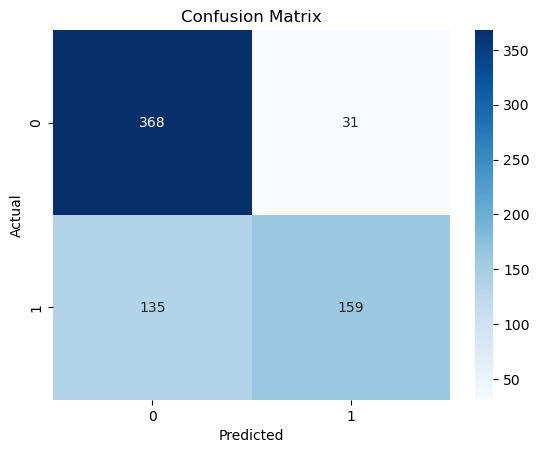

In [27]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model performs well in detecting real audio with a recall of 92%. 

For fake audio, the model achieves a precision of 84% and recall of 54%, indicating that while it correctly identifies many fake samples, some are still misclassified as real.

Overall, the model demonstrates balanced performance with an accuracy of 76% and no significant class bias.

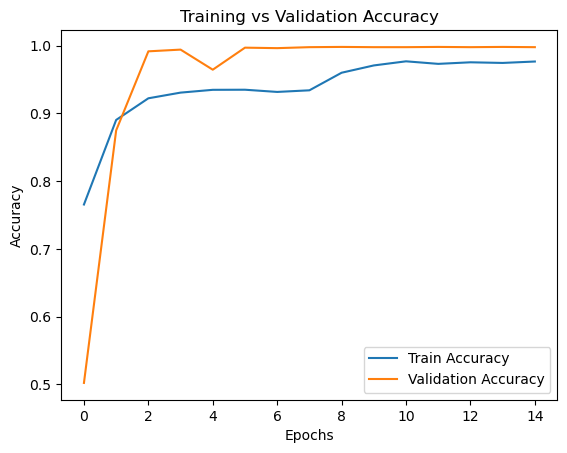

In [29]:
#Training History Graphs
plt.figure()
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

The graph shows that your CNN model learns very quickly, with both training and validation accuracy increasing sharply in the first few epochs. The validation accuracy reaches nearly 100% and stays consistently high, while training accuracy improves more gradually and stabilizes slightly below it. This indicates that the model is effectively capturing patterns in the data and generalizing well, but the unusually high and consistently higher validation accuracy compared to training may also suggest that the validation set is easier or that there could be some data leakage. Overall, the model appears to perform very well.

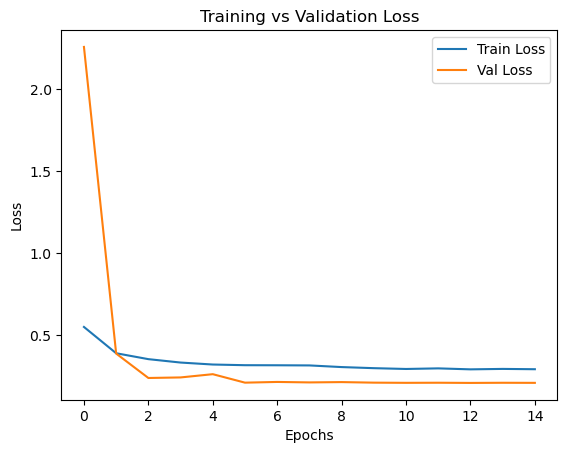

In [31]:
#Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

CNN-based deepfake audio detector shows promising generalization: the training loss steadily decreases and stabilizes, while the validation loss drops sharply after the first epoch and then flattens near zero. This suggests the model quickly learned to distinguish real from fake audio and is not overfitting, since validation performance remains consistently strong. In short, the graph indicates that the detector is both learning effectively and generalizing well to unseen data.

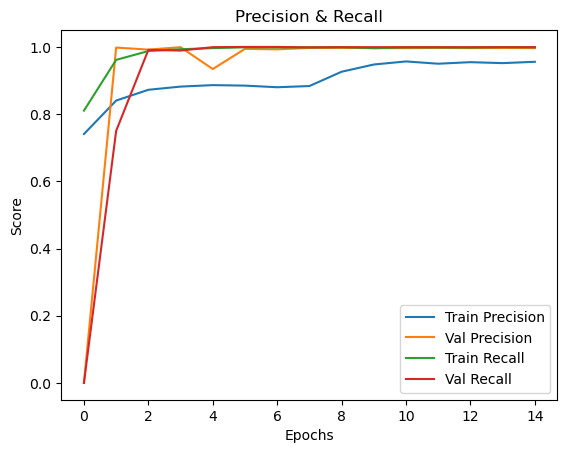

In [32]:
#Precision & Recall Curves
plt.figure()
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')

plt.xlabel('Epochs')
plt.ylabel('Score')
plt.title('Precision & Recall')
plt.legend()
plt.show()

This precision–recall curve shows that the CNN-based deepfake audio detector is performing exceptionally well. Both validation precision and recall shoot up to near-perfect values within the first few epochs and remain stable, while training metrics steadily climb and converge at high levels. That pattern indicates the model is not only learning effectively but also generalizing strongly — it’s consistently identifying fake audio with very few false positives (high precision) and catching nearly all fake samples (high recall). In short, the detector demonstrates robust accuracy and reliability across both training and validation sets.


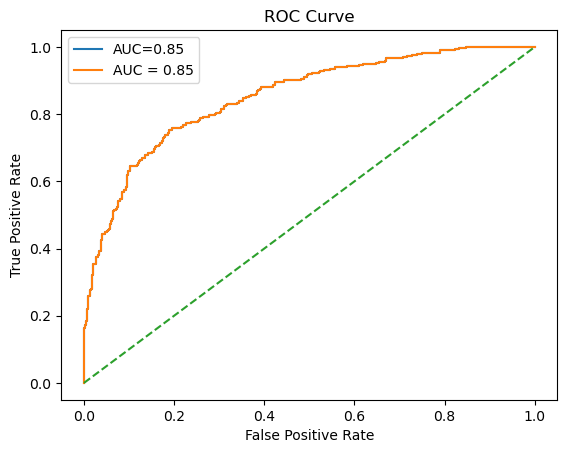

In [33]:
from sklearn.metrics import roc_curve,auc
fpr,tpr,thresolds=roc_curve(y_test,pred_probs)
roc_auc=auc(fpr,tpr)
plt.figure()
plt.plot(fpr,tpr,label=f'AUC={roc_auc:.2f}')

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


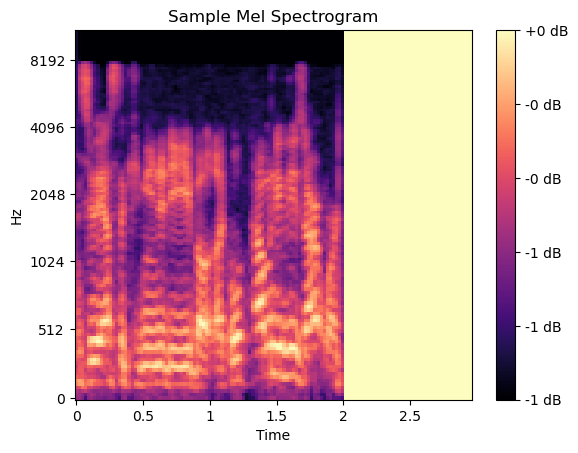

In [ ]:
import librosa.display

sample = X_train[0].squeeze()

plt.figure()
librosa.display.specshow(sample, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Sample Mel Spectrogram')
plt.show()
#Shows what model actually sees

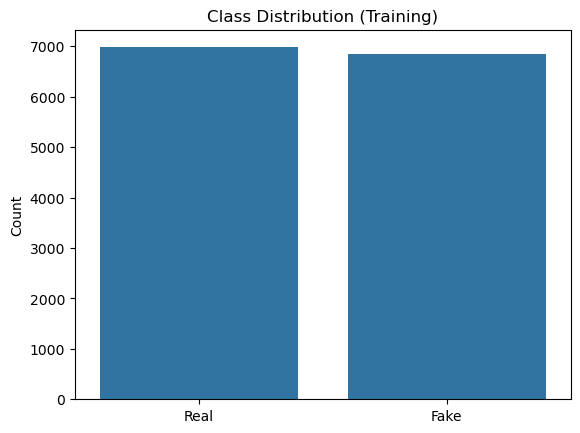

In [35]:
#Class Distribution Plot
import seaborn as sns
import numpy as np

labels = ['Real', 'Fake']
counts = np.bincount(y_train)

plt.figure()
sns.barplot(x=labels, y=counts)
plt.title("Class Distribution (Training)")
plt.ylabel("Count")
plt.show()

In [37]:
model.save("deepfake_audio_model.h5")

In [3]:
import os
print(os.getcwd())

e:\ML DL PROJECTS\DeepFake Audio Detection using CNN\notebooks


In [4]:
from tensorflow.keras.models import load_model
model = load_model(r"E:\ML DL PROJECTS\DeepFake Audio Detection using CNN\model\deepfake_audio_model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 945,475 (3.61 MB)

 Trainable params: 945,249 (3.61 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 2 (12.00 B)